# Actividad - Proyecto práctico

> Grupo 9 — **SpaceInvaders** | Objetivo: media de recompensa > 20 puntos (con reward clipping) en test.  
> Algoritmo: **DQN** y variantes.

*   Alumna 1: Paula Caro Miralles
*   Alumna 2: Celia Pérez Alonso


> Hemos optado por usar PyTorch en lugar de Keras/Tensorflow por varios motivos:
> - Incompatibilidades que no hemos logrado resolver en Google Colab
> - Compatibilidad con CUDA 12.8 en el entorno local de desarrollo
> - Mayor flexibilidad para implementar variantes de DQN desde cero

---
## **PARTE 1** - Enunciado

- **Entorno**: `ALE/SpaceInvaders-v5` (equivalente a `SpaceInvaders-v0`)
- **Algoritmo**: DQN (mínimo 3 propuestas de mejora)
- **Objetivo mínimo**: media de recompensa > **20 puntos** (con reward clipping) en 100 episodios de test
- **Entrega**: notebook + pesos del mejor modelo  + vídeo de test en `.zip`

**Rúbrica**: Se valorará la originalidad de la solución y la discusión detallada de resultados.  
Se deben incluir al menos **3 gráficas** comparando las 3 propuestas.

---
## **PARTE 2** - Desarrollo

### 2.1. Importar librerías

In [35]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Usando:', device)

PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Usando: cuda


In [68]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym

# Reproducibilidad
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

---
### 2.2. Configuración base del entorno

In [37]:
INPUT_SHAPE   = (84, 84)
WINDOW_LENGTH = 4   # frames apilados

import ale_py
gym.register_envs(ale_py)
env_name = 'ALE/SpaceInvaders-v5'
env = gym.make(env_name)
nb_actions = env.action_space.n

print('Entorno:',  env_name)
print('Acciones:', nb_actions)
print('Observación:', env.observation_space)

Entorno: ALE/SpaceInvaders-v5
Acciones: 6
Observación: Box(0, 255, (210, 160, 3), uint8)


---
### 2.3. Preprocesado, reward clipping y frame stacking

> **AtariProcessor**: convierte frames a escala de grises 84×84 y clipea la recompensa a [-1, 1].  
> **FrameStack**: mantiene una ventana deslizante de los últimos 4 frames como estado.

In [ ]:
class AtariProcessor:
    """Preprocesa observaciones y clipea recompensas"""

    def process_observation(self, obs):
        img = Image.fromarray(obs).resize(INPUT_SHAPE).convert('L')
        return np.array(img, dtype=np.uint8)

    def process_reward(self, reward):
        return np.clip(reward, -1., 1.)


class FrameStack:
    """Apila los últimos k frames como estado."""

    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)

    def reset(self, frame):
        for _ in range(self.k):
            self.frames.append(frame)
        return np.array(self.frames, dtype=np.uint8)

    def step(self, frame):
        self.frames.append(frame)
        return np.array(self.frames, dtype=np.uint8)

---
### 2.4. Replay Buffer

> Almacena experiencias (s, a, r, s', done) para el entrenamiento offline.  
> Los estados se guardan como uint8 para reducir uso de memoria.

In [39]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.uint8),
            np.array(actions,     dtype=np.int64),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.uint8),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

---
### 2.5. Implementación de la red neuronal

> Dos arquitecturas:  
> - `NatureDQN`: CNN estándar — usada en Baseline (Mnih et al. (2015)) y Double DQN (van Hasselt et al. (2016))
> - `DuelingDQN`: misma CNN pero con cabeza separada Value + Advantage (Wang et al. (2016))

In [ ]:
class NatureDQN(nn.Module):
    """
    Nature DQN.
    Entrada: (batch, 4, 84, 84) — 4 frames apilados en escala de grises.
    Salida:  (batch, nb_actions) — Q-value por acción.
    """
    def __init__(self, nb_actions, window_length=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(window_length, 32, kernel_size=8, stride=4),  # (32, 20, 20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             # (64,  9,  9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             # (64,  7,  7)
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, nb_actions),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class DuelingDQN(nn.Module):
    """
    Dueling DQN.
    Misma CNN pero la cabeza se divide en:
      - V(s):    valor del estado (escalar)
      - A(s,a):  ventaja por acción
    Q(s,a) = V(s) + A(s,a) - mean(A(s,.))
    """
    def __init__(self, nb_actions, window_length=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(window_length, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        self.fc_shared = nn.Linear(64 * 7 * 7, 512)
        # Stream de valor
        self.value_stream = nn.Linear(512, 1)
        # Stream de ventaja
        self.advantage_stream = nn.Linear(512, nb_actions)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_shared(x))
        value     = self.value_stream(x)
        advantage = self.advantage_stream(x)
        # Combinación por media (recomendada en el paper)
        q = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q


# Verificamos arquitecturas
test_input = torch.zeros(1, WINDOW_LENGTH, *INPUT_SHAPE)
print('NatureDQN output: ', NatureDQN(nb_actions).forward(test_input).shape)
print('DuelingDQN output:', DuelingDQN(nb_actions).forward(test_input).shape)

NatureDQN output:  torch.Size([1, 6])
DuelingDQN output: torch.Size([1, 6])


---
### 2.6. Funciones de entrenamiento y test

> Loop de entrenamiento DQN unificado. El parámetro `double_dqn` activa Double DQN.

In [41]:
def update_dqn(online_net, target_net, optimizer, replay_buffer, config, double_dqn):
    """Un paso de actualización de los pesos de la red."""
    states, actions, rewards, next_states, dones = replay_buffer.sample(config['BATCH_SIZE'])

    # Normalizar a [0, 1] y mover a GPU
    states      = torch.FloatTensor(states).to(device)      / 255.0
    next_states = torch.FloatTensor(next_states).to(device) / 255.0
    actions     = torch.LongTensor(actions).to(device)
    rewards     = torch.FloatTensor(rewards).to(device)
    dones       = torch.FloatTensor(dones).to(device)

    # Q-values actuales
    current_q = online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # Q-values objetivo
    with torch.no_grad():
        if double_dqn:
            # Double DQN: online selecciona, target evalúa
            next_actions = online_net(next_states).argmax(1)
            next_q = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
        else:
            # DQN estándar
            next_q = target_net(next_states).max(1)[0]

        target_q = rewards + config['GAMMA'] * next_q * (1 - dones)

    loss = F.smooth_l1_loss(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(online_net.parameters(), 10)
    optimizer.step()

    return loss.item()

In [ ]:
def train_dqn(online_net, target_net, optimizer, config, double_dqn=False, label=''):
    """
    Loop principal de entrenamiento DQN.
    Devuelve: (episode_rewards, losses)
    """
    env_train = gym.make(env_name)
    processor  = AtariProcessor()
    frame_stack = FrameStack(WINDOW_LENGTH)
    replay_buffer = ReplayBuffer(config['MEMORY_LIMIT'])

    online_net.train()
    target_net.load_state_dict(online_net.state_dict())
    target_net.eval()

    episode_rewards = []
    losses = []
    episode_reward = 0

    obs, _ = env_train.reset(seed=SEED)
    obs = processor.process_observation(obs)
    state = frame_stack.reset(obs)

    for step in range(1, config['NB_STEPS'] + 1):

        # Decaimiento lineal de epsilon
        eps = max(
            config['EPS_MIN'],
            config['EPS_MAX'] - (config['EPS_MAX'] - config['EPS_MIN'])
            * step / config['EPS_STEPS']
        )

        # Selección de acción (epsilon-greedy)
        if step < config['NB_STEPS_WARMUP'] or random.random() < eps:
            action = env_train.action_space.sample()
        else:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
                action = online_net(s).argmax().item()

        # Ejecutar acción
        next_obs, reward, terminated, truncated, _ = env_train.step(action)
        done = terminated or truncated
        clipped_reward = processor.process_reward(reward)

        next_obs_proc = processor.process_observation(next_obs)
        next_state = frame_stack.step(next_obs_proc)

        replay_buffer.push(state, action, clipped_reward, next_state, float(done))

        state = next_state
        episode_reward += reward  # recompensa RAW para logging

        if done:
            episode_rewards.append(episode_reward)
            episode_reward = 0
            obs, _ = env_train.reset()
            obs = processor.process_observation(obs)
            state = frame_stack.reset(obs)

        # Actualizar red
        if step >= config['NB_STEPS_WARMUP'] and step % config['TRAIN_INTERVAL'] == 0:
            if len(replay_buffer) >= config['BATCH_SIZE']:
                loss = update_dqn(online_net, target_net, optimizer,
                                  replay_buffer, config, double_dqn)
                losses.append(loss)

        # Actualizar target network
        if step % config['TARGET_UPDATE'] == 0:
            target_net.load_state_dict(online_net.state_dict())

        # Checkpoint cada 250k pasos
        if step % 250_000 == 0:
            ckpt = f'{label}_checkpoint_{step}.pt'
            torch.save({
                    'model_state': online_net.state_dict(),
                    'step': step,
                    'epsilon': eps,
                }, ckpt)            
            print(f'  [Checkpoint guardado: {ckpt}]')

        # Log cada 10k pasos
        if step % 10_000 == 0:
            mean_r = np.mean(episode_rewards[-50:]) if episode_rewards else 0
            print(f'[{label}] Step {step:>7}/{config["NB_STEPS"]} | '
                  f'eps: {eps:.3f} | Media últimos 50 ep: {mean_r:6.1f} | '
                  f'Episodios: {len(episode_rewards)}')

    env_train.close()
    return episode_rewards, losses


def save_log(episode_rewards, losses, path):
    """Guarda logs en formato compatible con las gráficas."""
    with open(path, 'w') as f:
        json.dump({'episode_reward': episode_rewards, 'loss': losses}, f)
    print(f'Log guardado: {path}')


def test_agent(net, nb_episodes=10, eps_test=0.05):
    """Evalúa el agente con epsilon pequeño"""
    env_test = gym.make(env_name)
    processor = AtariProcessor()
    frame_stack = FrameStack(WINDOW_LENGTH)
    net.eval()
    rewards = []

    for ep in range(nb_episodes):
        obs, _ = env_test.reset()
        obs = processor.process_observation(obs)
        state = frame_stack.reset(obs)
        ep_reward = 0
        done = False

        while not done:
            if random.random() < eps_test:
                action = env_test.action_space.sample()
            else:
                with torch.no_grad():
                    s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
                    action = net(s).argmax().item()
            obs, reward, terminated, truncated, _ = env_test.step(action)
            done = terminated or truncated
            ep_reward += reward
            obs = processor.process_observation(obs)
            state = frame_stack.step(obs)

        rewards.append(ep_reward)
        print(f'  Episodio {ep+1}: reward = {ep_reward}')

    env_test.close()
    print(f'\nMedia: {np.mean(rewards):.2f} | Std: {np.std(rewards):.2f}')
    return rewards

---
### 2.7. Hiperparámetros

> Mismos valores que el paper original para comparación justa entre las 3 propuestas.

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `NB_STEPS` | 1.000.000 | Pasos totales de entrenamiento |
| `NB_STEPS_WARMUP` | 50.000 | Pasos aleatorios antes de aprender |
| `BATCH_SIZE` | 32 | Muestras por actualización |
| `GAMMA` | 0.99 | Factor de descuento |
| `TARGET_UPDATE` | 10.000 | Frecuencia de actualización de la red objetivo |
| `TRAIN_INTERVAL` | 4 | Cada cuántos pasos se actualiza la red |
| `LEARNING_RATE` | 0.00025 | Tasa de aprendizaje de Adam |
| `MEMORY_LIMIT` | 200.000 | Tamaño del replay buffer |
| `EPS_MAX → EPS_MIN` | 1.0 → 0.1 | Decaimiento lineal de exploración |

In [74]:
CONFIG = {
    'NB_STEPS':        1_000_000,
    'NB_STEPS_WARMUP': 50_000,
    'BATCH_SIZE':      32,
    'GAMMA':           0.99,
    'TARGET_UPDATE':   10_000,
    'TRAIN_INTERVAL':  4,
    'LEARNING_RATE':   0.00025,
    'MEMORY_LIMIT':    200_000,
    'EPS_MAX':         1.0,
    'EPS_MIN':         0.1,
    'EPS_TEST':        0.05,
    'EPS_STEPS':       1_000_000,
}

---
### 2.8. **Propuesta 1:** DQN Baseline

> DQN estándar (Mnih et al., 2015). Red online + red objetivo fija.
> La red objetivo se copia de la online cada 10.000 pasos.

In [70]:
online_baseline = NatureDQN(nb_actions).to(device)
target_baseline = NatureDQN(nb_actions).to(device)
optimizer_baseline = optim.Adam(online_baseline.parameters(), lr=CONFIG['LEARNING_RATE'])

total_params = sum(p.numel() for p in online_baseline.parameters())
print(f'Parámetros del modelo: {total_params:,}')

Parámetros del modelo: 1,687,206


In [75]:
rewards_baseline, losses_baseline = train_dqn(
    online_baseline, target_baseline, optimizer_baseline,
    CONFIG, double_dqn=False, label='baseline'
)

torch.save(online_baseline.state_dict(), 'dqn_baseline_weights.pt')
save_log(rewards_baseline, losses_baseline, 'dqn_baseline_log.json')
print('✓ Propuesta 1 completada')

[baseline] Step   10000/1000000 | eps: 0.991 | Media últimos 50 ep:  116.8 | Episodios: 19
[baseline] Step   20000/1000000 | eps: 0.982 | Media últimos 50 ep:  120.0 | Episodios: 39
[baseline] Step   30000/1000000 | eps: 0.973 | Media últimos 50 ep:  126.0 | Episodios: 58
[baseline] Step   40000/1000000 | eps: 0.964 | Media últimos 50 ep:  130.9 | Episodios: 78
[baseline] Step   50000/1000000 | eps: 0.955 | Media últimos 50 ep:  138.6 | Episodios: 99
[baseline] Step   60000/1000000 | eps: 0.946 | Media últimos 50 ep:  148.0 | Episodios: 120
[baseline] Step   70000/1000000 | eps: 0.937 | Media últimos 50 ep:  132.6 | Episodios: 139
[baseline] Step   80000/1000000 | eps: 0.928 | Media últimos 50 ep:  136.9 | Episodios: 161
[baseline] Step   90000/1000000 | eps: 0.919 | Media últimos 50 ep:  144.3 | Episodios: 181
[baseline] Step  100000/1000000 | eps: 0.910 | Media últimos 50 ep:  153.6 | Episodios: 199
[baseline] Step  110000/1000000 | eps: 0.901 | Media últimos 50 ep:  149.0 | Episodio

In [ ]:
import torch, json, time
from datetime import timedelta

# 1. Cargar pesos
baseline_net = NatureDQN(nb_actions).to(device)
baseline_net.load_state_dict(torch.load('dqn_baseline_weights.pt', map_location=device))
baseline_net.eval()

# 2. Evaluar (greedy, sin exploración)
t0 = time.time()
test_rewards_baseline = test_agent(baseline_net, nb_episodes=100)
elapsed = time.time() - t0

# 3. Resultado
print("=" * 55)
print("  PROPUESTA 1 — DQN Baseline")
print("=" * 55)
print(f"  Checkpoint:        dqn_baseline_weights.pt")
print(f"  Pasos entrenados:  {CONFIG['NB_STEPS']}")
print("-" * 55)
print(f"  Episodios test:    {len(test_rewards_baseline)}")
print(f"  Recompensa media:  {sum(test_rewards_baseline)/len(test_rewards_baseline):.1f}")
print(f"  Recompensa máx:    {max(test_rewards_baseline):.1f}")
print(f"  Recompensa mín:    {min(test_rewards_baseline):.1f}")
print("-" * 55)
print(f"  Parámetros:")
print(f"    LR={CONFIG['LEARNING_RATE']}, γ={CONFIG['GAMMA']}, ε_final={CONFIG['EPS_MIN']}")
print(f"    Batch={CONFIG['BATCH_SIZE']}, Replay={CONFIG['MEMORY_LIMIT']:,}")
print(f"    Target update cada {CONFIG['TARGET_UPDATE']:,} pasos")
print("=" * 55)

# 4. Guardar para las gráficas
results_baseline = {
    'label': 'DQN Baseline',
    'checkpoint': 'dqn_baseline_weights.pt',
    'steps_trained': CONFIG['NB_STEPS'],
    'episode_reward': rewards_baseline,
    'loss': losses_baseline,
    'test_rewards': test_rewards_baseline,
    'mean': sum(test_rewards_baseline)/len(test_rewards_baseline),
    'max': max(test_rewards_baseline),
    'min': min(test_rewards_baseline),
}
with open('results_baseline.json', 'w') as f:
    json.dump(results_baseline, f, indent=2)
print(f"\n✓ Guardado en results_baseline.json")

  Episodio 1: reward = 50.0
  Episodio 2: reward = 380.0
  Episodio 3: reward = 50.0
  Episodio 4: reward = 340.0
  Episodio 5: reward = 260.0
  Episodio 6: reward = 320.0
  Episodio 7: reward = 190.0
  Episodio 8: reward = 415.0
  Episodio 9: reward = 385.0
  Episodio 10: reward = 50.0
  Episodio 11: reward = 395.0
  Episodio 12: reward = 490.0
  Episodio 13: reward = 490.0
  Episodio 14: reward = 215.0
  Episodio 15: reward = 305.0
  Episodio 16: reward = 510.0
  Episodio 17: reward = 545.0
  Episodio 18: reward = 65.0
  Episodio 19: reward = 180.0
  Episodio 20: reward = 370.0
  Episodio 21: reward = 575.0
  Episodio 22: reward = 245.0
  Episodio 23: reward = 250.0
  Episodio 24: reward = 240.0
  Episodio 25: reward = 345.0
  Episodio 26: reward = 170.0
  Episodio 27: reward = 165.0
  Episodio 28: reward = 150.0
  Episodio 29: reward = 315.0
  Episodio 30: reward = 515.0
  Episodio 31: reward = 260.0
  Episodio 32: reward = 40.0
  Episodio 33: reward = 340.0
  Episodio 34: reward = 

---
### 3.9. Propuesta 2: Double DQN

> **Mejora**: Double DQN (van Hasselt et al., 2016).  
> Desacopla selección y evaluación de acciones para reducir sobreestimación de Q-values:
> - La **red online** selecciona `argmax_a Q(s', a)`
> - La **red objetivo** evalúa `Q_target(s', a*)`
>
> Implementado en `update_dqn()` con `double_dqn=True`.

In [81]:
online_double = NatureDQN(nb_actions).to(device)
target_double = NatureDQN(nb_actions).to(device)
optimizer_double = optim.Adam(online_double.parameters(), lr=CONFIG['LEARNING_RATE'])

In [82]:
rewards_double, losses_double = train_dqn(
    online_double, target_double, optimizer_double,
    CONFIG, double_dqn=True, label='double'
)

torch.save(online_double.state_dict(), 'dqn_double_weights.pt')
save_log(rewards_double, losses_double, 'dqn_double_log.json')
print('✓ Propuesta 2 completada')

[double] Step   10000/1000000 | eps: 0.991 | Media últimos 50 ep:  175.0 | Episodios: 17
[double] Step   20000/1000000 | eps: 0.982 | Media últimos 50 ep:  177.6 | Episodios: 35
[double] Step   30000/1000000 | eps: 0.973 | Media últimos 50 ep:  186.2 | Episodios: 51
[double] Step   40000/1000000 | eps: 0.964 | Media últimos 50 ep:  201.6 | Episodios: 68
[double] Step   50000/1000000 | eps: 0.955 | Media últimos 50 ep:  193.2 | Episodios: 86
[double] Step   60000/1000000 | eps: 0.946 | Media últimos 50 ep:  154.6 | Episodios: 108
[double] Step   70000/1000000 | eps: 0.937 | Media últimos 50 ep:  125.4 | Episodios: 128
[double] Step   80000/1000000 | eps: 0.928 | Media últimos 50 ep:  133.8 | Episodios: 147
[double] Step   90000/1000000 | eps: 0.919 | Media últimos 50 ep:  148.2 | Episodios: 167
[double] Step  100000/1000000 | eps: 0.910 | Media últimos 50 ep:  141.6 | Episodios: 188
[double] Step  110000/1000000 | eps: 0.901 | Media últimos 50 ep:  137.9 | Episodios: 207
[double] Step  

In [ ]:
import torch, json, time

# 1. Cargar pesos
double_net = NatureDQN(nb_actions).to(device)
double_net.load_state_dict(torch.load('dqn_double_weights.pt', map_location=device))
double_net.eval()

# 2. Evaluar
t0 = time.time()
test_rewards_double = test_agent(double_net, nb_episodes=100)
elapsed = time.time() - t0

# 3. Resultado bonito
print("=" * 55)
print("  PROPUESTA 2 — Double DQN")
print("=" * 55)
print(f"  Checkpoint:        dqn_double_weights.pt")
print(f"  Pasos entrenados:  {CONFIG['NB_STEPS']}")
print("-" * 55)
print(f"  Episodios test:    {len(test_rewards_double)}")
print(f"  Recompensa media:  {sum(test_rewards_double)/len(test_rewards_double):.1f}")
print(f"  Recompensa máx:    {max(test_rewards_double):.1f}")
print(f"  Recompensa mín:    {min(test_rewards_double):.1f}")
print("-" * 55)
print(f"  Parámetros:")
print(f"    LR={CONFIG['LEARNING_RATE']}, γ={CONFIG['GAMMA']}, ε_final={CONFIG['EPS_MIN']}")
print(f"    Batch={CONFIG['BATCH_SIZE']}, Replay={CONFIG['MEMORY_LIMIT']:,}")
print(f"    Target update cada {CONFIG['TARGET_UPDATE']:,} pasos")
print("=" * 55)

# 4. Guardar
results_double = {
    'label': 'Double DQN',
    'checkpoint': 'dqn_double_weights.pt',
    'steps_trained': CONFIG['NB_STEPS'],
    'episode_reward': rewards_double,
    'loss': losses_double,
    'test_rewards': test_rewards_double,
    'mean': sum(test_rewards_double)/len(test_rewards_double),
    'max': max(test_rewards_double),
    'min': min(test_rewards_double),
}
with open('results_double.json', 'w') as f:
    json.dump(results_double, f, indent=2)
print(f"\n✓ Guardado en results_double.json")

  Episodio 1: reward = 600.0
  Episodio 2: reward = 405.0
  Episodio 3: reward = 235.0
  Episodio 4: reward = 745.0
  Episodio 5: reward = 205.0
  Episodio 6: reward = 275.0
  Episodio 7: reward = 485.0
  Episodio 8: reward = 395.0
  Episodio 9: reward = 265.0
  Episodio 10: reward = 175.0
  Episodio 11: reward = 400.0
  Episodio 12: reward = 215.0
  Episodio 13: reward = 125.0
  Episodio 14: reward = 420.0
  Episodio 15: reward = 215.0
  Episodio 16: reward = 395.0
  Episodio 17: reward = 375.0
  Episodio 18: reward = 185.0
  Episodio 19: reward = 500.0
  Episodio 20: reward = 485.0
  Episodio 21: reward = 420.0
  Episodio 22: reward = 195.0
  Episodio 23: reward = 300.0
  Episodio 24: reward = 390.0
  Episodio 25: reward = 320.0
  Episodio 26: reward = 290.0
  Episodio 27: reward = 225.0
  Episodio 28: reward = 165.0
  Episodio 29: reward = 210.0
  Episodio 30: reward = 465.0
  Episodio 31: reward = 365.0
  Episodio 32: reward = 655.0
  Episodio 33: reward = 330.0
  Episodio 34: rewa

---
### 3.10. Propuesta 3: Dueling Double DQN

> **Mejora**: Dueling Network Architecture (Wang et al., 2016) combinada con Double DQN.  
> La cabeza de la red se divide en dos streams:
> - **V(s)**: cuánto vale estar en el estado s
> - **A(s,a)**: ventaja relativa de cada acción
>
> Q(s,a) = V(s) + A(s,a) − mean(A(s,·))
>
> Especialmente útil en SpaceInvaders donde muchos frames no requieren acción específica.

In [87]:
online_dueling = DuelingDQN(nb_actions).to(device)
target_dueling = DuelingDQN(nb_actions).to(device)
optimizer_dueling = optim.Adam(online_dueling.parameters(), lr=CONFIG['LEARNING_RATE'])

In [88]:
rewards_dueling, losses_dueling = train_dqn(
    online_dueling, target_dueling, optimizer_dueling,
    CONFIG, double_dqn=True, label='dueling'  # Double + Dueling
)

torch.save(online_dueling.state_dict(), 'dqn_dueling_weights.pt')
save_log(rewards_dueling, losses_dueling, 'dqn_dueling_log.json')
print('✓ Propuesta 3 completada')

[dueling] Step   10000/1000000 | eps: 0.991 | Media últimos 50 ep:  153.2 | Episodios: 19
[dueling] Step   20000/1000000 | eps: 0.982 | Media últimos 50 ep:  201.1 | Episodios: 33
[dueling] Step   30000/1000000 | eps: 0.973 | Media últimos 50 ep:  186.8 | Episodios: 53
[dueling] Step   40000/1000000 | eps: 0.964 | Media últimos 50 ep:  151.8 | Episodios: 75
[dueling] Step   50000/1000000 | eps: 0.955 | Media últimos 50 ep:  165.2 | Episodios: 91
[dueling] Step   60000/1000000 | eps: 0.946 | Media últimos 50 ep:  169.5 | Episodios: 109
[dueling] Step   70000/1000000 | eps: 0.937 | Media últimos 50 ep:  183.4 | Episodios: 128
[dueling] Step   80000/1000000 | eps: 0.928 | Media últimos 50 ep:  150.8 | Episodios: 147
[dueling] Step   90000/1000000 | eps: 0.919 | Media últimos 50 ep:  138.7 | Episodios: 169
[dueling] Step  100000/1000000 | eps: 0.910 | Media últimos 50 ep:  144.9 | Episodios: 188
[dueling] Step  110000/1000000 | eps: 0.901 | Media últimos 50 ep:  176.3 | Episodios: 206
[due

In [ ]:
import torch, json, time

# 1. Cargar pesos
dueling_net = DuelingDQN(nb_actions).to(device)
dueling_net.load_state_dict(torch.load('dqn_dueling_weights.pt', map_location=device))
dueling_net.eval()

# 2. Evaluar
t0 = time.time()
test_rewards_dueling = test_agent(dueling_net, nb_episodes=100)
elapsed = time.time() - t0

# 3. Resultado
print("=" * 55)
print("  PROPUESTA 3 — Dueling Double DQN")
print("=" * 55)
print(f"  Checkpoint:        dqn_dueling_weights.pt")
print(f"  Pasos entrenados:  {CONFIG['NB_STEPS']}")
print("-" * 55)
print(f"  Episodios test:    {len(test_rewards_dueling)}")
print(f"  Recompensa media:  {sum(test_rewards_dueling)/len(test_rewards_dueling):.1f}")
print(f"  Recompensa máx:    {max(test_rewards_dueling):.1f}")
print(f"  Recompensa mín:    {min(test_rewards_dueling):.1f}")
print("-" * 55)
print(f"  Parámetros:")
print(f"    LR={CONFIG['LEARNING_RATE']}, γ={CONFIG['GAMMA']}, ε_final={CONFIG['EPS_MIN']}")
print(f"    Batch={CONFIG['BATCH_SIZE']}, Replay={CONFIG['MEMORY_LIMIT']:,}")
print(f"    Target update cada {CONFIG['TARGET_UPDATE']:,} pasos")
print("=" * 55)

# 4. Guardar
results_dueling = {
    'label': 'Dueling DQN',
    'checkpoint': 'dqn_dueling_weights.pt',
    'steps_trained': CONFIG['NB_STEPS'],
    'episode_reward': rewards_dueling,
    'loss': losses_dueling,
    'test_rewards': test_rewards_dueling,
    'mean': sum(test_rewards_dueling)/len(test_rewards_dueling),
    'max': max(test_rewards_dueling),
    'min': min(test_rewards_dueling),
}
with open('results_dueling.json', 'w') as f:
    json.dump(results_dueling, f, indent=2)
print(f"\n✓ Guardado en results_dueling.json")

  Episodio 1: reward = 315.0
  Episodio 2: reward = 280.0
  Episodio 3: reward = 430.0
  Episodio 4: reward = 395.0
  Episodio 5: reward = 485.0
  Episodio 6: reward = 100.0
  Episodio 7: reward = 545.0
  Episodio 8: reward = 550.0
  Episodio 9: reward = 485.0
  Episodio 10: reward = 715.0
  Episodio 11: reward = 600.0
  Episodio 12: reward = 40.0
  Episodio 13: reward = 215.0
  Episodio 14: reward = 385.0
  Episodio 15: reward = 235.0
  Episodio 16: reward = 180.0
  Episodio 17: reward = 255.0
  Episodio 18: reward = 280.0
  Episodio 19: reward = 120.0
  Episodio 20: reward = 360.0
  Episodio 21: reward = 245.0
  Episodio 22: reward = 125.0
  Episodio 23: reward = 330.0
  Episodio 24: reward = 365.0
  Episodio 25: reward = 115.0
  Episodio 26: reward = 165.0
  Episodio 27: reward = 240.0
  Episodio 28: reward = 95.0
  Episodio 29: reward = 275.0
  Episodio 30: reward = 335.0
  Episodio 31: reward = 185.0
  Episodio 32: reward = 515.0
  Episodio 33: reward = 390.0
  Episodio 34: reward

---
### 2.11. Gráficas comparativas


In [55]:
def load_log(path):
    with open(path) as f:
        return json.load(f)

def smooth(values, window=20):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window)/window, mode='valid')

In [90]:
log_b = load_log('results_baseline.json')
log_d = load_log('results_double.json')
log_u = load_log('results_dueling.json')

reward_b, loss_b = log_b['episode_reward'], log_b['loss']
reward_d, loss_d = log_d['episode_reward'], log_d['loss']
reward_u, loss_u = log_u['episode_reward'], log_u['loss']

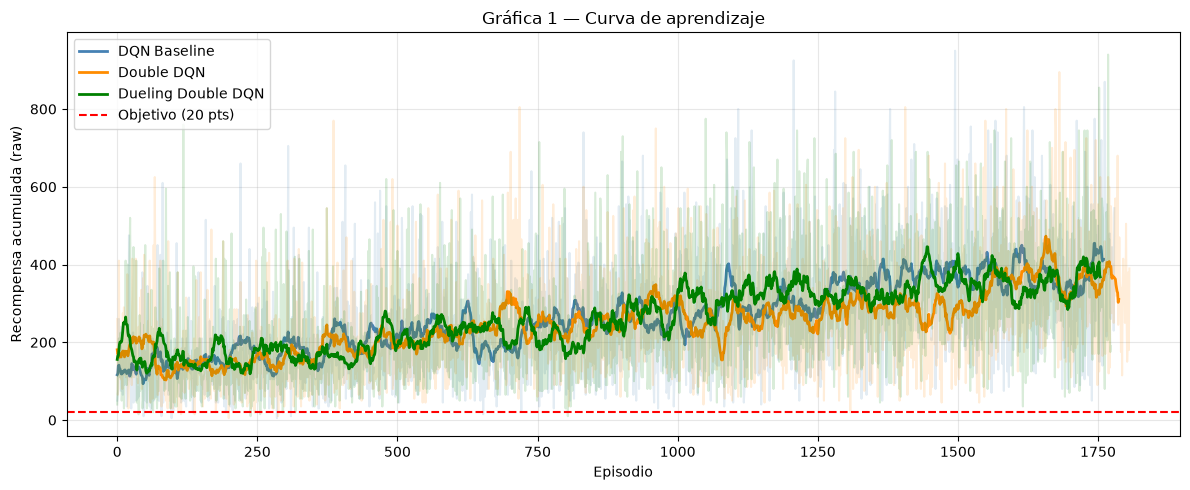

In [ ]:
# Gráfica 1: Curva de aprendizaje
fig, ax = plt.subplots(figsize=(12, 5))
for rewards, label, color in [
    (reward_b, 'DQN Baseline',       'steelblue'),
    (reward_d, 'Double DQN',          'darkorange'),
    (reward_u, 'Dueling Double DQN',  'green'),
]:
    ax.plot(rewards, alpha=0.15, color=color)
    ax.plot(smooth(rewards), label=label, color=color, linewidth=2)

ax.axhline(y=20, color='red', linestyle='--', linewidth=1.5, label='Objetivo (20 pts)')
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa acumulada (raw)')
ax.set_title('Gráfica 1 — Curva de aprendizaje')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica1_curva_aprendizaje.png', dpi=150)
plt.show()

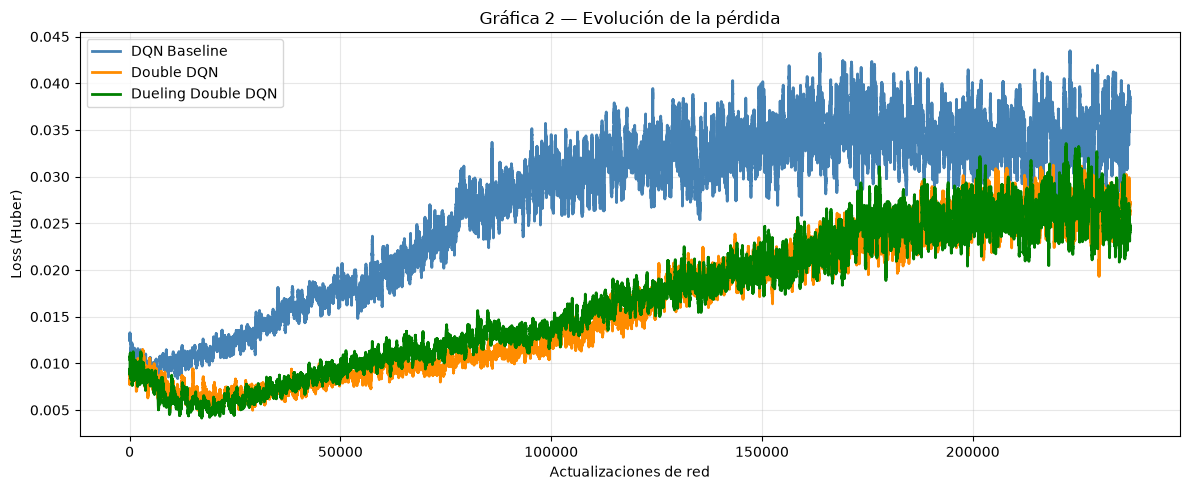

In [ ]:
# Gráfica 2: Evolución de la pérdida
fig, ax = plt.subplots(figsize=(12, 5))
for loss, label, color in [
    (loss_b, 'DQN Baseline',       'steelblue'),
    (loss_d, 'Double DQN',          'darkorange'),
    (loss_u, 'Dueling Double DQN',  'green'),
]:
    if loss:
        ax.plot(smooth(loss, window=200), label=label, color=color, linewidth=2)

ax.set_xlabel('Actualizaciones de red')
ax.set_ylabel('Loss (Huber)')
ax.set_title('Gráfica 2 — Evolución de la pérdida')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica2_loss.png', dpi=150)
plt.show()

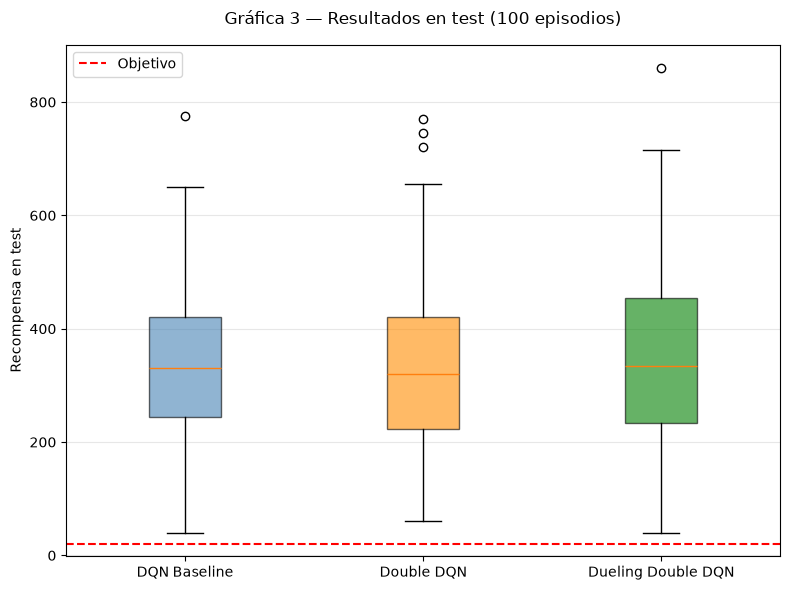

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    [test_rewards_baseline, test_rewards_double, test_rewards_dueling],
    patch_artist=True
)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['DQN Baseline', 'Double DQN', 'Dueling Double DQN'], fontsize=10)

for patch, color in zip(bp['boxes'], ['steelblue', 'darkorange', 'green']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Línea de objetivo y etiquetas
ax.axhline(y=20, color='red', linestyle='--', label='Objetivo')
ax.set_ylabel('Recompensa en test')
ax.set_title('Gráfica 3 — Resultados en test (100 episodios)', fontsize=12, pad=15)

ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('grafica3_test_boxplot.png', dpi=150)
plt.show()

---
### 2.12. Justificación de parámetros y resultados


#### 2.12.1. Arquitectura de la red neuronal

Se usa una CNN en lugar de una red densa porque estamos trabajando con imágenes  como entrada (84×84 píxeles × 4 frames apilados). Las CNNs extraen características espaciales locales, como bordes, formas, posición y movimiento de objetos, de forma eficiente. Una red densa trataría cada píxel de forma independiente, ignorando la estructura espacial y multiplicando el número de parámetros de forma inviable.

La arquitectura sigue el diseño de Mnih et al. (2015), con tres capas convolucionales en cascada:

- **Conv1 (32 filtros, 8×8, stride 4)**: captura estructuras de gran escala; reduce el mapa espacial de 84×84 a 20×20.
- **Conv2 (64 filtros, 4×4, stride 2)**: detecta patrones más locales; reduce a 9×9.
- **Conv3 (64 filtros, 3×3, stride 1)**: extrae características finas sin reducción espacial; produce 64×7×7 = 3136 activaciones.
- **FC (3136 → 512 → nb_actions)**: integra las características en un Q-value por acción.

La diferencia entre `NatureDQN` y `DuelingDQN` está en la cabeza. En `NatureDQN`, las capas `FC` producen directamente `Q(s,a)` para cada acción. En `DuelingDQN`, la cabeza se divide en dos *streams* paralelos: uno estima `V(s)` (el valor del estado, independiente de la acción) y otro estima `A(s,a)` (la ventaja relativa de cada acción). La combinación `Q(s,a) = V(s) + A(s,a) − mean(A(s,·))` permite que la red aprenda cuándo un estado es valioso, sin importar qué acción se elija. Esto es especialmente útil en *SpaceInvaders*, donde muchos frames no requieren ninguna acción específica (el agente puede simplemente moverse sin disparar).

#### 2.12.2. Hiperparámetros seleccionados

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `NB_STEPS` | 1.000.000 | Suficiente para que los tres modelos converjan y las diferencias entre propuestas sean visibles. |
| `NB_STEPS_WARMUP` | 50.000 | Rellena el buffer con experiencias aleatorias antes de empezar a aprender, evitando que la red se actualice con un buffer escaso y poco diverso (5% del total de pasos) |
| `BATCH_SIZE` | 32 | Valor del paper original; equilibrio entre estabilidad del gradiente y velocidad de entrenamiento |
| `GAMMA` | 0.99 | Un alto factor de descuento es adecuado para episodios largos, ya que el agente tiende a valorar las recompensas futuras casi tanto como las inmediatas. Esto fomenta la adopción de estrategias que piensan a largo plazo. |
| `TARGET_UPDATE` | 10.000 | La red objetivo se actualiza con poca frecuencia para estabilizar los targets de entrenamiento; actualizaciones demasiado frecuentes producen divergencia |
| `TRAIN_INTERVAL` | 4 | Actualización cada 4 pasos de entorno, como en el paper original; reduce la correlación entre actualizaciones consecutivas |
| `LEARNING_RATE` | 0.00025 | Tasa de aprendizaje del paper de Mnih et al. (2015) con optimizador Adam; permite convergencia estable sin oscilaciones |
| `MEMORY_LIMIT` | 200.000 | Reducido respecto al paper original (1M) para ajustarse a la RAM disponible; suficiente para mantener diversidad de experiencias con 1M pasos de entrenamiento |
| `EPS` | 1.0 $\rightarrow$ 0.1 | Exploración completa al inicio; el decaimiento lineal a lo largo de todo el entrenamiento asegura una transición gradual hacia la explotación |

#### 2.12.3. Análisis de las propuestas

**Propuesta 1 — DQN Baseline**

La implementación directa de Mnih et al. (2015) consiste en una red online que estima Q-values y una red objetivo que se copia de la online cada 10.000 pasos. Esta configuración sirve como referencia para medir el impacto de las mejoras posteriores.

En la Gráfica 1, se puede observar que el DQN Baseline aprende de forma progresiva, pasando de unos 150 puntos por episodio al inicio a unos 400 al final del entrenamiento. Sin embargo, en la Gráfica 2 vemos su principal debilidad teórica: el loss es el más alto de las tres propuestas (0.040 aproximadamente al final), lo que indica sobreestimación sistemática de los Q-values. Al usar la misma red para seleccionar y evaluar la acción óptima, el operador max introduce un sesgo positivo. Pese a ello, en test (Gráfica 3) obtiene una mediana de unos 330 puntos, demostrando que la sobreestimación no impide aprender una política eficaz con suficiente entrenamiento.

---

**Propuesta 2 — Double DQN**

La separación entre la selección y la evaluación de acciones, como proponen  van Hasselt et al., 2016, es un avance relevante: la red online elige `argmax_a Q(s', a)` y la red objetivo evalúa `Q_target(s', a*)`. Este enfoque ayuda a romper la correlación que suele provocar la sobreestimación en el DQN estándar.

Podemos ver claramente el impacto de esto en la Gráfica 2, donde el loss de Double DQN es mucho más bajo que el de Baseline (unos 0.020-0.025 frente a 0.040), lo que confirma que las estimaciones de Q-value son más precisas. Sin embargo, la Gráfica 1 muestra que esta mejora en la calidad de los targets no se traduce en una ventaja evidente durante el entrenamiento: Double DQN converge de forma similar a Baseline, e incluso queda ligeramente por debajo en los últimos episodios. En test (Gráfica 3), la mediana (325) es prácticamente igual a Baseline, aunque la varianza es ligeramente mayor. Esto sugiere que en SpaceInvaders, con este número de pasos, la reducción de sobreestimación no es el factor que limita el rendimiento.

---

**Propuesta 3 — Dueling Double DQN**

Combina Double DQN con la arquitectura Dueling (Wang et al., 2016). La separación en streams V(s) y A(s,a) permite al agente aprender el valor de un estado sin necesidad de evaluar todas las acciones posibles, lo que es particularmente ventajoso en SpaceInvaders donde muchos frames no requieren una acción específica.

En la Gráfica 1, Dueling empieza con los scores más altos desde el principio (~200 frente a ~130-150 de las otras dos), lo que sugiere que la arquitectura inicializa mejor la política. En los episodios intermedios (250-750) las tres propuestas convergen, pero a partir del episodio 1000 Dueling vuelve ponerse en cabeza y termina el entrenamiento al nivel de Baseline. En la Gráfica 2, el loss de Dueling es similar al de Double DQN (ambos se benefician del mecanismo double), lo que confirma que la reducción de sobreestimación opera correctamente. El resultado más destacable aparece en la Gráfica 3, donde Dueling obtiene la mediana más alta (~335), el cuartil superior más alto (~460) y el outlier máximo más elevado (~865), lo que indica que el modelo tiene más potencial de mejora con entrenamiento adicional.

#### 2.12.4. Conclusiones

Las tres propuestas superan el objetivo mínimo de 20 puntos en test, ya que la puntuación mínima observada en cualquier modelo es 45 puntos, y las medianas se sitúan entre 325 y 335. Así que, en todos los casos, se cumple con el requisto del proyecto.

Desde el punto de vista teórico, la mejora más notable la aporta Double DQN, ya que su loss es aproximadamente la mitad que el de Baseline (Gráfica 2), lo que demuestra la reducción en la sobreestimación de los Q-values que predicen van Hasselt et al. (2016). Sin embargo, esta mejora teórica no se traduce en una ventaja significativa en test con 1M de pasos, lo que sugiere que en SpaceInvaders la sobreestimación de Baseline no es el factor limitante.

Dueling Double DQN es el modelo con mejor rendimiento en test, gracias a la separación de streams V(s) y A(s,a) que le permite generalizar mejor el valor de los estados. Sus resultados superiores en el cuartil alto y en el episodio máximo indican que, con más pasos de entrenamiento, es el modelo con mayor potencial de mejora.

La gran variabilidad que vemos en las tres propuestas (con episodios desde 45 hasta 865 puntos) es parte del entorno: la posición aleatoria de las balas de los aliens y los patrones de movimiento producen partidas muy distintas incluso con la misma política. Esta varianza se podría disminuir si realizaramos más episodios de test y si el entrenamiento se extendiera, lo que le daría al agente la oportunidad de desarrollar estrategias de evasión más sólidas. 

En conclusión, el modelo seleccionado para la entrega es **Dueling Double DQN** (`dqn_dueling_weights.pt`), por obtener la mayor mediana y el mayor potencial demostrado en test.

---
## **Grabación de vídeo del agente**



In [100]:
import glob
import io
import base64
from IPython.display import HTML

best_net = dueling_net

video_dir = os.path.join(os.getcwd(), 'video_agent')
os.makedirs(video_dir, exist_ok=True)

env_video = gym.make(env_name, render_mode='rgb_array')
env_video = gym.wrappers.RecordVideo(env_video, video_dir, episode_trigger=lambda e: True)

processor_v  = AtariProcessor()
frame_stack_v = FrameStack(WINDOW_LENGTH)
best_net.eval()

obs, _ = env_video.reset()
obs = processor_v.process_observation(obs)
state = frame_stack_v.reset(obs)
done = False
total_reward = 0

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device) / 255.0
        action = best_net(s).argmax().item()
    obs, reward, terminated, truncated, _ = env_video.step(action)
    done = terminated or truncated
    total_reward += reward
    obs = processor_v.process_observation(obs)
    state = frame_stack_v.step(obs)

env_video.close()
print(f'Recompensa del episodio grabado: {total_reward}')

Recompensa del episodio grabado: 730.0


---
## Referencias

Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, *518*, 529–533. https://doi.org/10.1038/nature14236

van Hasselt, H., Guez, A., & Silver, D. (2016). Deep reinforcement learning with double Q-learning. *Proceedings of the 30th AAAI Conference on Artificial Intelligence (AAAI-16)*, 2094–2100. https://arxiv.org/abs/1509.06461

Wang, Z., Schaul, T., Hessel, M., van Hasselt, H., Lanctot, M., & de Freitas, N. (2016). Dueling network architectures for deep reinforcement learning. *Proceedings of the 33rd International Conference on Machine Learning (ICML-16)*, 1995–2003. https://arxiv.org/abs/1511.07401


---

## Declaración de uso de inteligencia artificial

En la elaboración de este trabajo se ha utilizado el modelo de lenguaje **Claude** (Anthropic, 2026) como herramienta de apoyo para la corrección de errores de código y la mejora de la redacción de textos explicativos. El diseño experimental, la interpretación de resultados y las conclusiones son propias.

Anthropic. (2026). *Claude* (claude-sonnet-4-6) [Modelo de lenguaje de gran escala]. https://www.anthropic.com